In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
df = pd.read_csv("mall_customer.csv")
df.head()

,ID_Pelanggan,Jenis_Kelamin,Usia,Pendapatan_Tahunan_kUSD,Skor_Belanja
0,1,Laki-laki,19,15,39
1,2,Laki-laki,21,15,81
2,3,Perempuan,20,16,6
3,4,Perempuan,23,16,77
4,5,Perempuan,31,17,40


In [7]:
print("Jumlah baris x kolom :", df.shape)
print("Missing Value        :", df.isnull().sum().sum())
print("Duplikat             :", df.duplicated().sum())
df.describe()

Jumlah baris x kolom : (200, 5)
Missing Value        : 0
Duplikat             : 0


,ID_Pelanggan,Usia,Pendapatan_Tahunan_kUSD,Skor_Belanja
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
fitur_2d = ["Pendapatan_Tahunan_kUSD", "Skor_Belanja"]
X2 = df[fitur_2d].values
X2[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

In [9]:
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

#SOAL 1 MENENTUKAN ELBOW & SILHOUETTE

Elbow Method

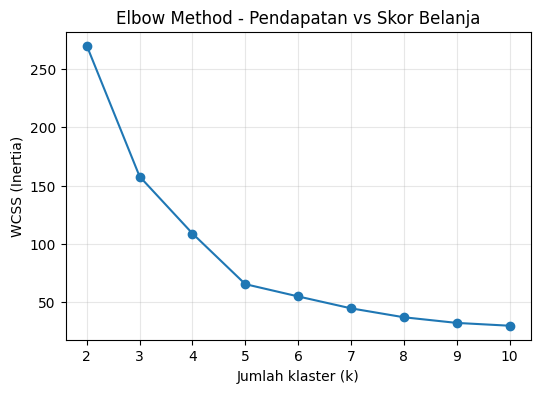

In [10]:
wcss2 = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X2_scaled)
    wcss2.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(k_range), wcss2, marker="o")
plt.xlabel("Jumlah klaster (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method - Pendapatan vs Skor Belanja")
plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/elbow_2fitur.png", bbox_inches="tight")
plt.show()

#Silhouette Method

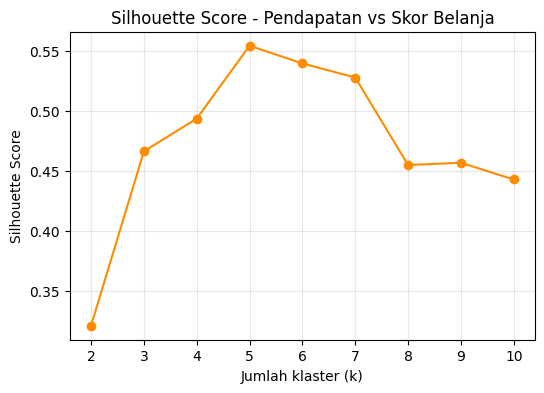

k= 2 | WCSS=  269.69 | Silhouette=0.3213
k= 3 | WCSS=  157.70 | Silhouette=0.4666
k= 4 | WCSS=  108.92 | Silhouette=0.4939
k= 5 | WCSS=   65.57 | Silhouette=0.5547
k= 6 | WCSS=   55.06 | Silhouette=0.5399
k= 7 | WCSS=   44.86 | Silhouette=0.5281
k= 8 | WCSS=   37.23 | Silhouette=0.4552
k= 9 | WCSS=   32.39 | Silhouette=0.4571
k=10 | WCSS=   29.98 | Silhouette=0.4432

>> k disarankan (silhouette tertinggi): k = 5


In [11]:
sil2 = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X2_scaled)
    sil2.append(silhouette_score(X2_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(list(k_range), sil2, marker="o", color="darkorange")
plt.xlabel("Jumlah klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Pendapatan vs Skor Belanja")
plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/silhouette_2fitur.png", bbox_inches="tight")
plt.show()

for k, w, s in zip(k_range, wcss2, sil2):
    print(f"k={k:2d} | WCSS={w:8.2f} | Silhouette={s:.4f}")

k_optimal_2d = list(k_range)[int(np.argmax(sil2))]
print(f"\n>> k disarankan (silhouette tertinggi): k = {k_optimal_2d}")

#KMEANS & CLUSTERING

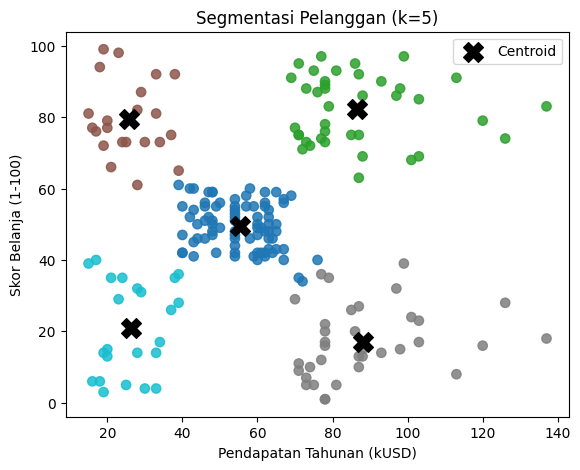

In [12]:
K_FINAL_2D = k_optimal_2d   # = 5
km2 = KMeans(n_clusters=K_FINAL_2D, n_init=10, random_state=RANDOM_STATE)
df["Cluster_2Fitur"] = km2.fit_predict(X2_scaled)
centers2 = scaler2.inverse_transform(km2.cluster_centers_)

plt.figure(figsize=(6.5,5))
plt.scatter(df["Pendapatan_Tahunan_kUSD"], df["Skor_Belanja"],
            c=df["Cluster_2Fitur"], cmap="tab10", s=45, alpha=0.85)
plt.scatter(centers2[:,0], centers2[:,1], c="black", marker="X", s=200, label="Centroid")
plt.xlabel("Pendapatan Tahunan (kUSD)")
plt.ylabel("Skor Belanja (1-100)")
plt.title(f"Segmentasi Pelanggan (k={K_FINAL_2D})")
plt.legend()
plt.savefig(f"{OUTPUT_DIR}/clusters_2fitur.png", bbox_inches="tight")
plt.show()

#JAWABAN SOAL 1

Berdasarkan analisis menggunakan fitur Pendapatan Tahunan dan Skor Belanja saja, metode elbow menunjukkan penurunan WCSS yang tajam dari k=2 hingga k=5 (dari 269,69 turun menjadi 65,57), kemudian turun signifikan setelah k=5 (55,06 di k=6, 44,86 di k=7, dan seterusnya), sehingga titik siku terlihat jelas di k=5. Sejalan dengan itu, metode silhouette juga menunjukkan skor tertinggi tepat di k=5 dengan nilai 0,5547, lebih tinggi dibanding k=4 (0,4939) maupun k=6 (0,5399). Karena kedua metode secara independen sama-sama merekomendasikan k=5, kepercayaan terhadap pilihan jumlah cluster ini menjadi lebih kuat. Grafik sebaran data juga mendukung pilihan ini secara visual, karena ketika diplot antara Pendapatan Tahunan dan Skor Belanja, terlihat lima kumpulan titik yang terpisah cukup jelas membentuk pola menyerupai bintang lima: kelompok kanan-atas dengan pendapatan dan belanja sama-sama tinggi, kelompok kanan-bawah dengan pendapatan tinggi namun belanja rendah, kelompok kiri-atas dengan pendapatan rendah namun belanja tinggi, kelompok kiri-bawah dengan pendapatan dan belanja sama-sama rendah, serta satu kelompok besar di tengah dengan pendapatan dan belanja yang sama-sama sedang. 

#SOAL 2 NAMA SEGMEN DAN STRATEGI PEMASARAN


In [13]:
ringkasan = df.groupby("Cluster_2Fitur")[fitur_2d].mean().round(1)
ringkasan = ringkasan.rename(columns={
    "Pendapatan_Tahunan_kUSD": "Rata2_Pendapatan",
    "Skor_Belanja": "Rata2_Skor_Belanja",
})
ringkasan["Jumlah_Pelanggan"] = df.groupby("Cluster_2Fitur").size()
ringkasan

,Rata2_Pendapatan,Rata2_Skor_Belanja,Jumlah_Pelanggan
Cluster_2Fitur,,,
0,55.3,49.5,81
1,86.5,82.1,39
2,25.7,79.4,22
3,88.2,17.1,35
4,26.3,20.9,23


In [14]:
med_income = df["Pendapatan_Tahunan_kUSD"].median()
med_score = df["Skor_Belanja"].median()

def beri_nama_segmen(row):
    pendapatan_tinggi = row["Rata2_Pendapatan"] >= med_income
    skor_tinggi = row["Rata2_Skor_Belanja"] >= med_score
    if pendapatan_tinggi and skor_tinggi:
        return "Premium (Pendapatan Tinggi, Boros)", \
               "Program loyalitas & preview produk baru"
    if pendapatan_tinggi and not skor_tinggi:
        return "Hemat Berpenghasilan Tinggi", \
               "Promo personal & layanan concierge untuk memancing belanja"
    if not pendapatan_tinggi and skor_tinggi:
        return "Boros Berpenghasilan Terbatas", \
               "Cicilan/paylater & program poin agar tetap loyal"
    return "Hemat & Berpenghasilan Rendah (Standar)", \
           "Produk value-for-money & diskon musiman lewat email/SMS"

hasil = ringkasan.reset_index().apply(
    lambda r: beri_nama_segmen(r), axis=1, result_type="expand"
)
ringkasan_final = ringkasan.reset_index()
ringkasan_final["Nama_Segmen"] = hasil[0]
ringkasan_final["Usulan_Strategi_Pemasaran"] = hasil[1]
ringkasan_final.to_csv(f"{OUTPUT_DIR}/ringkasan_segmen_2fitur.csv", index=False)
ringkasan_final

,Cluster_2Fitur,Rata2_Pendapatan,Rata2_Skor_Belanja,Jumlah_Pelanggan,Nama_Segmen,Usulan_Strategi_Pemasaran
0,0,55.3,49.5,81,Hemat & Berpenghasilan Rendah (Standar),Produk value-for-money & diskon musiman lewat ...
1,1,86.5,82.1,39,"Premium (Pendapatan Tinggi, Boros)",Program loyalitas & preview produk baru
2,2,25.7,79.4,22,Boros Berpenghasilan Terbatas,Cicilan/paylater & program poin agar tetap loyal
3,3,88.2,17.1,35,Hemat Berpenghasilan Tinggi,Promo personal & layanan concierge untuk meman...
4,4,26.3,20.9,23,Hemat & Berpenghasilan Rendah (Standar),Produk value-for-money & diskon musiman lewat ...


#JAWABAN SOAL 2

Cluster pertama merupakan kelompok terbesar dengan 81 pelanggan, berpenghasilan sedang (rata-rata 55,3 kUSD) dan skor belanja sedang (49,5), sehingga bisa disebut sebagai segmen "Standar" yang paling cocok didekati dengan promosi umum lewat email atau SMS serta diskon musiman untuk menjaga keterikatan mayoritas pelanggan. Cluster kedua berisi 39 pelanggan dengan pendapatan tinggi (86,5 kUSD) dan skor belanja tinggi (82,1), sehingga dinamai segmen "Premium atau Boros", yang paling tepat ditawarkan program loyalitas eksklusif, akses awal ke produk baru, dan layanan VIP karena mereka adalah pelanggan paling bernilai. Cluster ketiga terdiri dari 22 pelanggan dengan pendapatan rendah (25,7 kUSD) namun skor belanja tinggi (79,4), disebut sebagai segmen "Boros meski Berpenghasilan Terbatas", yang cocok ditawarkan skema cicilan atau paylater serta program poin agar tetap loyal tanpa memberatkan keuangan mereka. Cluster keempat berisi 35 pelanggan dengan pendapatan tinggi (88,2 kUSD) namun skor belanja rendah (17,1), tepat sesuai contoh di soal yaitu segmen "Berpenghasilan Tinggi tetapi Hemat", yang membutuhkan pendekatan berbeda seperti promo personal yang relevan, layanan concierge, atau penekanan pada kualitas premium untuk memancing mereka berbelanja lebih banyak. Terakhir, cluster kelima berisi 23 pelanggan dengan pendapatan rendah (26,3 kUSD) dan skor belanja rendah (20,9), disebut segmen "Hemat dan Berpenghasilan Rendah", yang paling cocok ditawarkan produk value-for-money dan diskon besar musiman dengan komunikasi pemasaran berbiaya rendah.

In [15]:
df.to_csv(f"{OUTPUT_DIR}/mall_customer_hasil_cluster_2fitur.csv", index=False)
print("Tersimpan:", f"{OUTPUT_DIR}/mall_customer_hasil_cluster_2fitur.csv")

Tersimpan: output/mall_customer_hasil_cluster_2fitur.csv
